# Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("../data/raw/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Basic Information of the dataset

In [3]:
df.shape

(541909, 8)

In [4]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


# Handling Missing Data

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
missing_customer = df["CustomerID"].isnull().sum()

print("Missing CustomerID:", missing_customer)
print("Percentage:", round(missing_customer / len(df) * 100, 2), "%")

Missing CustomerID: 135080
Percentage: 24.93 %


<b>Key Point: </b> Around 25% of the customerIDs are missing

In [8]:
df[df["CustomerID"].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


<b>Key Point: </b>Only customerID is missing and some description but not other transaction details

In [9]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

missing_revenue = (
    df[df["CustomerID"].isnull()]["Revenue"].sum()
)

total_revenue = df["Revenue"].sum()

print(
    f"Revenue share: {missing_revenue / total_revenue * 100:.2f}%"
)

Revenue share: 14.85%


<b>Key Point: </b>They have a huge 14.85% revenue share

<b>Point to Notice: </b>Same Invoice id means same customer. But the issue is that sometimes same invoice no has entire customer id as nan. So can't recover from that. So better to drop them

In [10]:
clean_df = df.dropna(subset=["CustomerID"])

# EDA

## Create Revenue Column

In [11]:
clean_df["Revenue"] = (
    clean_df["Quantity"] *
    clean_df["UnitPrice"]
)

## Number of Customers

In [12]:
clean_df["CustomerID"].nunique()

4372

## No of purchases

In [13]:
clean_df["InvoiceNo"].nunique()

22190

## Total Revenue

In [14]:
clean_df["Revenue"].sum()

np.float64(8300065.813999999)

## Average Revenue per order

In [15]:
invoice_revenue = (
    clean_df.groupby("InvoiceNo")["Revenue"]
    .sum()
)

invoice_revenue.mean()

np.float64(374.0453273546642)

## Revenue per Country

In [16]:
country_revenue = (
    clean_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    6767873.394
Netherlands        284661.540
EIRE               250285.220
Germany            221698.210
France             196712.840
Australia          137077.270
Switzerland         55739.400
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

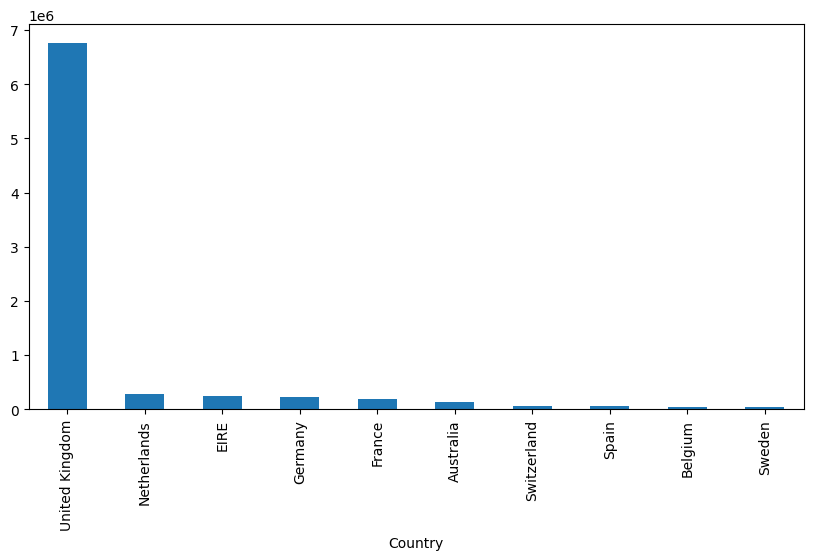

In [17]:
country_revenue.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.show()

<b>Key Point: </b>We can see United Kingdom has the higest revenue among any other country. That also leading by a large margin. Maybe due to higher store count there.

## Monthly Revenue

In [18]:
clean_df["YearMonth"] = (
    clean_df["InvoiceDate"]
    .dt.to_period("M")
)

In [19]:
monthly_revenue = (
    clean_df.groupby("YearMonth")["Revenue"]
    .sum()
)

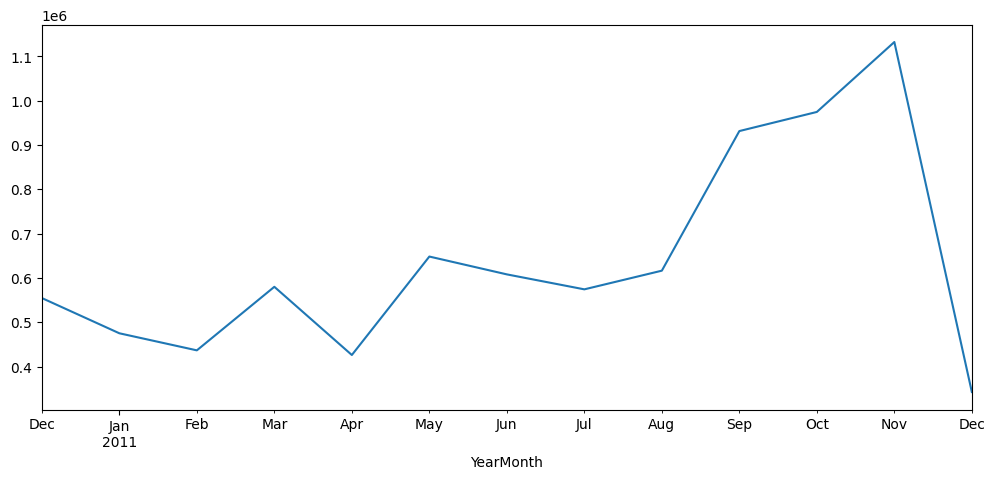

In [20]:
monthly_revenue.plot(
    figsize=(12,5)
)
plt.show()

<b>Key Point: </b> Sudden spike near the last quarter of the year. till now can't draw a decision line why

## Product demographic

In [21]:
top_products = (
    clean_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

top_products.head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53215
JUMBO BAG RED RETROSPOT               45066
ASSORTED COLOUR BIRD ORNAMENT         35314
WHITE HANGING HEART T-LIGHT HOLDER    34147
PACK OF 72 RETROSPOT CAKE CASES       33409
POPCORN HOLDER                        30504
RABBIT NIGHT LIGHT                    27094
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25321
PACK OF 60 PINK PAISLEY CAKE CASES    24163
Name: Quantity, dtype: int64

In [22]:
top_revenue_products = (
    clean_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_revenue_products.head(10)

Description
REGENCY CAKESTAND 3 TIER              132870.40
WHITE HANGING HEART T-LIGHT HOLDER     93823.85
JUMBO BAG RED RETROSPOT                83236.76
PARTY BUNTING                          67687.53
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56499.22
RABBIT NIGHT LIGHT                     51137.80
CHILLI LIGHTS                          45936.81
PAPER CHAIN KIT 50'S CHRISTMAS         41500.48
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: Revenue, dtype: float64

<b>Key points: </b>Upon analysing the products. We can somewhat understand the effect of festive season Christmas for such massive revenue in CakeStand, Light holder, Red bag, party, picnic basket etc.

## Customer Revenue Contribution

In [23]:
customer_revenue = (
    clean_df.groupby("CustomerID")["Revenue"]
    .sum()
)

In [24]:
customer_revenue.describe()

count      4372.000000
mean       1898.459701
std        8219.345141
min       -4287.630000
25%         293.362500
50%         648.075000
75%        1611.725000
max      279489.020000
Name: Revenue, dtype: float64

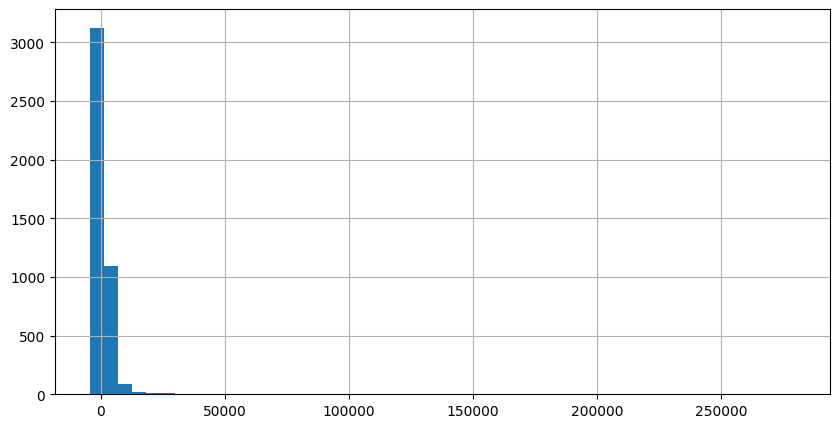

In [25]:
customer_revenue.hist(
    bins=50,
    figsize=(10,5)
)
plt.show()

In [26]:
customer_revenue = customer_revenue.sort_values(
    ascending=False
)

cum_pct = (
    customer_revenue.cumsum()
    / customer_revenue.sum()
)

In [27]:
(cum_pct <= 0.8).sum()

np.int64(1170)

<b>Key Point: </b>Around 26.76% customers generate the 80% of the revenue

## Purchase frequency

In [28]:
purchase_frequency = (
    clean_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

In [29]:
purchase_frequency.describe()

count    4372.000000
mean        5.075480
std         9.338754
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       248.000000
Name: InvoiceNo, dtype: float64

<b>Key Point: </b>While a customer bought as high has 248 times we also have as low as 1 time.

## Purchase value

In [30]:
invoice_value = (
    clean_df.groupby("InvoiceNo")["Revenue"]
    .sum()
)

In [31]:
invoice_value.describe()

count     22190.000000
mean        374.045327
std        2018.482869
min     -168469.600000
25%          87.962500
50%         241.505000
75%         418.022500
max      168469.600000
Name: Revenue, dtype: float64

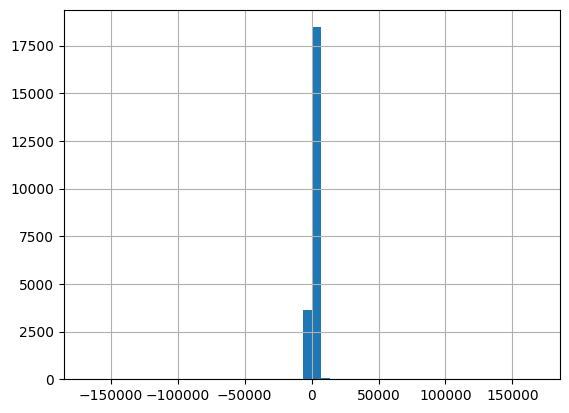

In [32]:
invoice_value.hist(
    bins=50
)
plt.show()

<b>Key Point: </b> Most purchase values are within 375 bucks

In [33]:
first_purchase = (
    clean_df.groupby("CustomerID")
    ["InvoiceDate"]
    .min()
)

In [34]:
last_purchase = (
    clean_df.groupby("CustomerID")
    ["InvoiceDate"]
    .max()
)

In [35]:
lifetime = (
    last_purchase -
    first_purchase
).dt.days

In [36]:
lifetime.describe()

count    4372.000000
mean      133.385865
std       132.845467
min         0.000000
25%         0.000000
50%        97.500000
75%       255.250000
max       373.000000
Name: InvoiceDate, dtype: float64

# RFM

In [37]:
clean_df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [38]:
cutoff_date = pd.Timestamp("2011-09-01")

In [39]:
historical = clean_df[
    clean_df["InvoiceDate"] <= cutoff_date
]

future = clean_df[
    clean_df["InvoiceDate"] > cutoff_date
]

snapshot_date = cutoff_date + pd.Timedelta(days=1)

rfm = historical.groupby("CustomerID").agg(
    {
        "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
        "InvoiceNo": "nunique",
        "Revenue": "sum"
    }
)

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [40]:
future_customers = set(
    future["CustomerID"].unique()
)

In [41]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [42]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,226,2,0.00
12347.0,30,5,2790.86
12348.0,149,3,1487.24
12350.0,211,1,334.40
12352.0,163,8,601.18


In [43]:
rfm.describe()

,Recency,Frequency,Monetary
count,3360.000000,3360.000000,3360.000000
mean,92.467560,4.119643,1464.020158
std,77.497282,6.847027,5538.524078
min,1.000000,1.000000,-4287.630000
25%,27.000000,1.000000,243.630000
50%,72.000000,2.000000,532.960000
75%,147.000000,4.000000,1311.357500
max,274.000000,134.000000,175638.940000


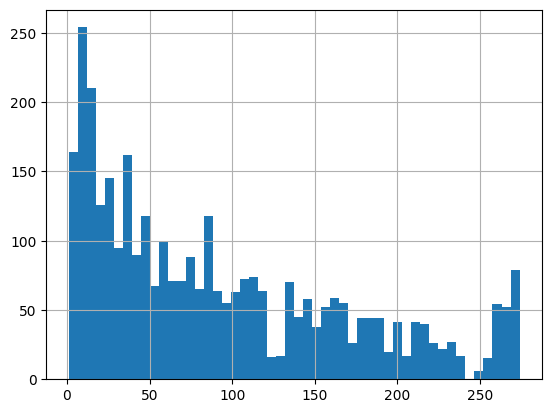

In [44]:
rfm["Recency"].hist(bins=50)
plt.show()

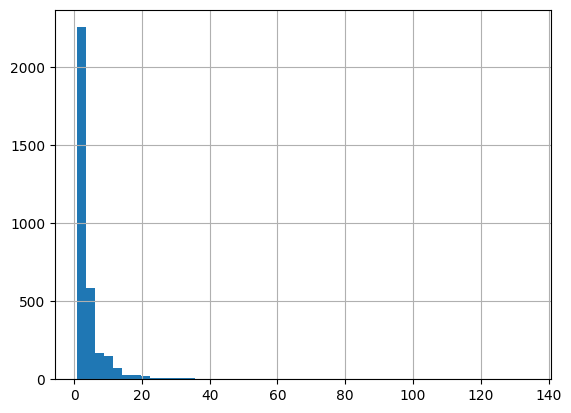

In [45]:
rfm["Frequency"].hist(bins=50)
plt.show()

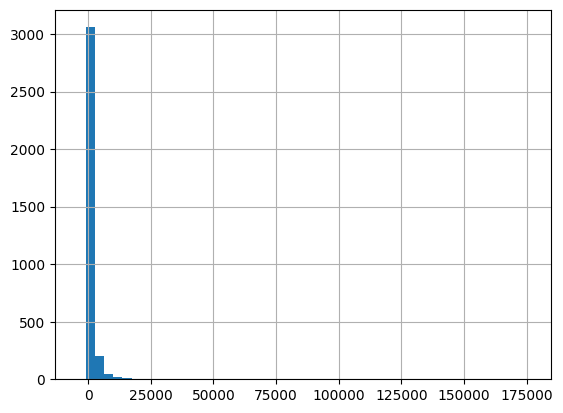

In [46]:
rfm["Monetary"].hist(bins=50)
plt.show()

## RFM Score

In [47]:
rfm["R"] = pd.qcut(
    rfm["Recency"],
    q=4,
    labels=[4,3,2,1]
)

In [48]:
rfm["F"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=4,
    labels=[1,2,3,4]
)

In [49]:
rfm["M"] = pd.qcut(
    rfm["Monetary"],
    q=4,
    labels=[1,2,3,4]
)

In [50]:
rfm["RFM_Score"] = (
    rfm["R"].astype(str) +
    rfm["F"].astype(str) +
    rfm["M"].astype(str)
)

In [51]:
rfm["RFM_Total"] = (
    rfm["R"].astype(int) +
    rfm["F"].astype(int) +
    rfm["M"].astype(int)
)

## Segment Customers

In [52]:
def segment(row):

    if row["R"] >= 4 and row["F"] >= 4:
        return "Champions"

    elif row["R"] >= 3 and row["F"] >= 3:
        return "Loyal Customers"

    elif row["R"] >= 3 and row["F"] <= 2:
        return "Potential Loyalists"

    elif row["R"] <= 2 and row["F"] >= 3:
        return "At Risk"

    else:
        return "Others"

In [53]:
rfm["Segment"] = rfm.apply(segment, axis=1)

In [54]:
rfm["Segment"].value_counts()

Segment
Others                 1178
Loyal Customers         720
Potential Loyalists     502
At Risk                 496
Champions               464
Name: count, dtype: int64

In [55]:
rfm.groupby("Segment")["Monetary"].mean()

Segment
At Risk                 969.216393
Champions              5684.306056
Loyal Customers        1601.023944
Others                  344.034321
Potential Loyalists     483.762392
Name: Monetary, dtype: float64

## Business Insights

In [56]:
rfm.groupby("Segment")["Monetary"].sum()

Segment
At Risk                 480731.331
Champions              2637518.010
Loyal Customers        1152737.240
Others                  405272.430
Potential Loyalists     242848.721
Name: Monetary, dtype: float64

In [57]:
(
    rfm["Segment"] == "Champions"
).mean() * 100

np.float64(13.80952380952381)

In [58]:
rfm.groupby("Segment")["Monetary"].sum() \
   / rfm["Monetary"].sum() * 100

Segment
At Risk                 9.772734
Champions              53.617814
Loyal Customers        23.433869
Others                  8.238739
Potential Loyalists     4.936845
Name: Monetary, dtype: float64

In [59]:
rfm.to_csv(
    "../data/processed/rfm.csv"
)

# Model Training

In [60]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,3360.000000,3360.000000,3360.000000
mean,92.467560,4.119643,1464.020158
std,77.497282,6.847027,5538.524078
min,1.000000,1.000000,-4287.630000
25%,27.000000,1.000000,243.630000
50%,72.000000,2.000000,532.960000
75%,147.000000,4.000000,1311.357500
max,274.000000,134.000000,175638.940000


In [61]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
R            0
F            0
M            0
RFM_Score    0
RFM_Total    0
Segment      0
dtype: int64

In [62]:
rfm = rfm[rfm["Monetary"] > 0]
rfm_log = rfm.copy()

rfm_log["Frequency"] = np.log1p(
    rfm_log["Frequency"]
)

rfm_log["Monetary"] = np.log1p(
    rfm_log["Monetary"]
)

In [63]:
rfm_log.isnull().sum()

Recency      0
Frequency    0
Monetary     0
R            0
F            0
M            0
RFM_Score    0
RFM_Total    0
Segment      0
dtype: int64

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    rfm_log[
        ["Recency", "Frequency", "Monetary"]
    ]
)

In [65]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

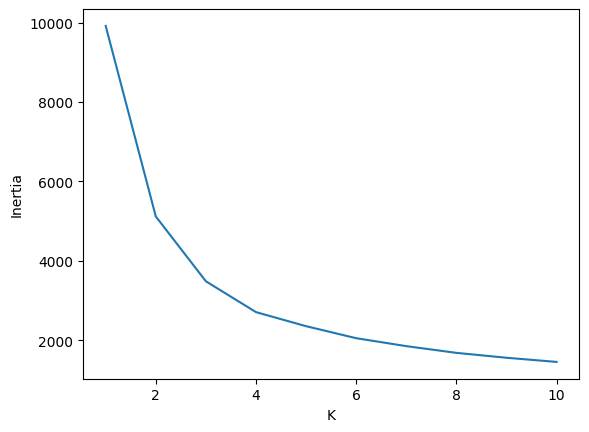

In [66]:
plt.plot(range(1,11), inertia)
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [67]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(
    scaled_features
)

In [68]:
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Score,RFM_Total,Segment,Cluster
CustomerID,,,,,,,,,,
12347.0,30,5,2790.86,3,4,4,344,11,Loyal Customers,0
12348.0,149,3,1487.24,1,3,4,134,8,At Risk,0
12350.0,211,1,334.40,1,1,2,112,4,Others,1
12352.0,163,8,601.18,1,4,3,143,8,At Risk,0
12353.0,105,1,89.00,2,1,1,211,4,Others,2


In [69]:
cluster_summary = (
    rfm.groupby("Cluster")
    [["Recency","Frequency","Monetary"]]
    .mean()
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,52.341057,4.139944,1253.548129
1,197.339326,1.429213,343.369539
2,64.401993,1.549280,310.782637
3,22.872979,15.293303,6914.577829


In [70]:
cluster_names = {
    0: "Loyal Customers",
    1: "At Risk",
    2: "Potential Loyalists",
    3: "Champions"
}

In [71]:
rfm["Cluster_Name"] = (
    rfm["Cluster"]
    .map(cluster_names)
)

In [72]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    scaled_features
)

In [73]:
plot_df = pd.DataFrame({
    "PC1": pca_features[:,0],
    "PC2": pca_features[:,1],
    "Cluster": rfm["Cluster"]
})

<Axes: xlabel='PC1', ylabel='PC2'>

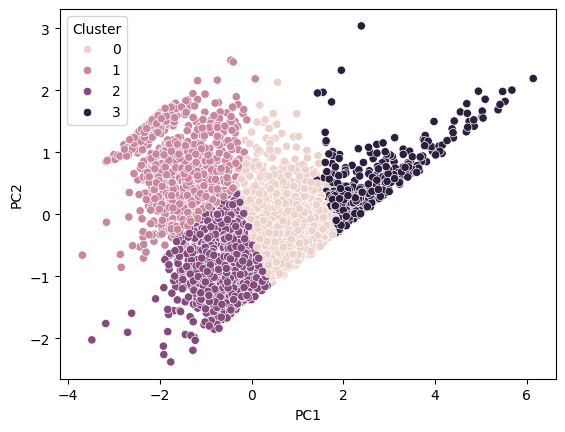

In [74]:
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster"
)

In [75]:
pd.crosstab(
    rfm["Segment"],
    rfm["Cluster_Name"]
)

Cluster_Name,At Risk,Champions,Loyal Customers,Potential Loyalists
Segment,,,,
At Risk,121,20,273,76
Champions,0,309,153,2
Loyal Customers,0,104,519,93
Others,769,0,46,324
Potential Loyalists,0,0,88,408


# Churn Prediction

In [76]:
customer_lifetime = historical.groupby(
    "CustomerID"
)["InvoiceDate"].agg(
    lambda x: (x.max() - x.min()).days
)

rfm["CustomerLifetime"] = customer_lifetime

In [77]:
purchase_frequency_days = historical.groupby(
    "CustomerID"
)["InvoiceDate"].agg(
    lambda x: (
        (x.max() - x.min()).days /
        max(len(x.unique()) - 1, 1)
    )
)

rfm["AvgDaysBetweenPurchases"] = purchase_frequency_days

In [78]:
rfm["UniqueProducts"] = historical.groupby(
    "CustomerID"
)["StockCode"].nunique()

In [79]:
rfm["TotalQuantity"] = historical.groupby(
    "CustomerID"
)["Quantity"].sum()

In [80]:
rfm["Churn"] = (
    ~rfm.index.isin(future_customers)
).astype(int)

In [81]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "CustomerLifetime",
    "AvgDaysBetweenPurchases",
    "UniqueProducts",
    "TotalQuantity"
]

In [82]:
rfm["AverageOrderValue"] = (
    rfm["Monetary"] /
    rfm["Frequency"]
)

In [83]:
X = rfm[features]

In [84]:
y = rfm["Churn"]

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [86]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [87]:
y_pred = model.predict(X_test)

In [88]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.75      0.74      0.75       394
           1       0.63      0.64      0.63       267

    accuracy                           0.70       661
   macro avg       0.69      0.69      0.69       661
weighted avg       0.70      0.70      0.70       661



In [89]:
from sklearn.metrics import confusion_matrix

confusion_matrix(
    y_test,
    y_pred
)

array([[291, 103],
       [ 95, 172]])

In [90]:
import joblib

joblib.dump(
    model,
    "../backend/app/model/churn_model.pkl"
)

['../backend/app/model/churn_model.pkl']

# CLV

In [91]:
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Score,RFM_Total,Segment,Cluster,Cluster_Name,CustomerLifetime,AvgDaysBetweenPurchases,UniqueProducts,TotalQuantity,Churn,AverageOrderValue
CustomerID,,,,,,,,,,,,,,,,,
12347.0,30,5,2790.86,3,4,4,344,11,Loyal Customers,0,Loyal Customers,237,59.250000,82,1590,0,558.172000
12348.0,149,3,1487.24,1,3,4,134,8,At Risk,0,Loyal Customers,109,54.500000,22,2124,0,495.746667
12350.0,211,1,334.40,1,1,2,112,4,Others,1,At Risk,0,0.000000,17,197,1,334.400000
12352.0,163,8,601.18,1,4,3,143,8,At Risk,0,Loyal Customers,34,4.857143,26,188,0,75.147500
12353.0,105,1,89.00,2,1,1,211,4,Others,2,Potential Loyalists,0,0.000000,4,20,1,89.000000


In [92]:
future_spend = (
    future.groupby("CustomerID")["Revenue"]
    .sum()
)

In [93]:
rfm["FutureSpend"] = (
    rfm.index.map(future_spend)
)

In [94]:
rfm["FutureSpend"] = (
    rfm["FutureSpend"]
    .fillna(0)
)

In [95]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "CustomerLifetime",
    "UniqueProducts",
    "TotalQuantity"
]

In [96]:
X = rfm[features]

y = rfm["FutureSpend"]

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [98]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [99]:
predictions = model.predict(X_test)

In [100]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        predictions
    )
)

print(
    "R2:",
    r2_score(
        y_test,
        predictions
    )
)

MAE: 710.0607860363085
R2: 0.5611861841013532


In [101]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
2,Monetary,0.783215
3,AverageOrderValue,0.061831
6,TotalQuantity,0.052143
5,UniqueProducts,0.029324
1,Frequency,0.027244
0,Recency,0.026505
4,CustomerLifetime,0.019738
